# 第50篇 | 随机森林：集成学习的威力

> 这是「数据分析从入门到精通」系列的第 50 篇。决策树学完了，这篇来学它的"进化版"——随机森林。"三个臭皮匠顶个诸葛亮"，多棵决策树投票，准确率更高、稳定性更强，是工程实践中最常用的算法之一。

嗨，我是小荷～ 上篇学了决策树，今天来学它的"升级版"：**随机森林**。

---

## 一、什么是随机森林？

**核心思想**

把多个弱学习器组合成强学习器，三个臭皮匠，顶个诸葛亮。

- 森林： 指的是由多棵 决策树（Decision Tree） 组成的集合。
- 随机： 指的是在构建每一棵决策树时，算法会引入两种随机性，确保每棵树都与众不同。
最终，对于分类任务，森林通过 投票（多数决） 给出结果；对于回归任务，则通过 取平均值 给出结果。

随机森林通过让每棵树在略有不同的数据和特征视角下进行训练，创造了一个多样化的专家委员会。 即使其中一些树犯了错误，其他正确的树也能通过投票将其纠正，从而获得比单棵决策树更稳定、更强大的性能。

**看个例子**

比如你想构建一个模型，根据当天的天气状况来预测是否去露营。

你手里有 3 个字段：

- 天气（Weather）：晴天 / 下雨
- 温度（Temperature）：炎热 / 寒冷
- 风速（Wind）：大风 / 微风

我们按以下步骤来构建这个模型。

- 步骤 1：构建“森林”（专家委员会）

  随机森林并不仅仅是将同一棵树复制 100 次。它使用了两个聪明的小技巧来确保每棵树都有些许不同（在机器学习中我们称之为多样性）：

  - 随机数据（袋装法 / Bagging）： 树 1 观察的是过去 5 月份的露营历史数据；树 2 观察的是 7 月份的数据；树 3 观察的则是 10 月份的数据。
  - 随机特征，从全部特征中随机选取一个子集： 树 1 只被允许查看“天气”和“温度”这两条线索；树 2 只被允许查看“温度”和“风速”。因为它们看到的数据不同，使用的线索也不同，所以它们最终会成长为完全不同的形状。

- 步骤 2：进行预测（民主投票过程）

  比如今天是星期六。目前的实际天气状况是：晴天、寒冷、大风。你将这些条件输入到你的随机森林模型中。让我们来看看森林中的三棵树会如何投票：
   - 树 1（天气专家）它的逻辑： 优先看天气。它的推导路径： 今天是晴天吗？ --> 是的。它的投票结果： “出发去露营”
   - 树 2（风速专家）它的逻辑： 优先看风速。它的推导路径： 今天风大吗？--> 是的 --> 帐篷可能会被吹走。它的投票结果： “乖乖呆在家里”
   - 树 3（舒适度专家）它的逻辑： 综合看天气和温度。它的推导路径： 今天是晴天吗？ --> 是的。今天冷吗？ --> 是的，但阳光晒着应该还能忍受。它的投票结果： “出发去露营！”

- 步骤 3：汇总投票现在，随机森林开始统计森林中所有树的投票（假设整个森林一共有 100 棵树）：“出发去露营” 获得：78 票“乖乖呆在家里” 获得：22 票凭借 78% 的压倒性多数票，随机森林输出了最终答案：你应该出发去露营！

为什么这比单棵决策树更好？如果你当时只听从了树 2 的意见，你就会因为刮大风而选择呆在家里，从而错过一个阳光明媚的美好日子。单棵决策树是出了名的死板和偏激（过拟合 / Overfitting）。它们会过度机械地死记硬背某些特定规则。如果单棵树犯了错，你的整个预测就会直接报废。而通过将 100 棵树组合在一起，树 2 的失误会被树 1 和树 3 的智慧所抵消、修正。这就是为什么随机森林会成为数据科学中最可靠、最受欢迎的算法之一——它通过民主投票的力量，完美驯服了单棵决策树容易跑偏的野性错误。

In [43]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# ==========================================================
# 1. 创建简单的历史数据（过去的露营历史记录）
# ==========================================================
# 特征（线索）：Weather     （天气：0代表下雨，1代表晴天）
#              Temperature （温度：0代表寒冷，1代表炎热）
#              Wind        （风速：0代表微风，1代表大风）
# 目标（答案）：Go_Camping  （是否去露营：0代表不去，1代表去）

data = {
    'Weather':     [1, 0, 1, 1, 0, 1, 0, 1], # 1=晴天, 0=下雨
    'Temperature': [1, 0, 1, 0, 1, 0, 0, 1], # 1=炎热, 0=寒冷
    'Wind':        [0, 1, 1, 0, 0, 1, 0, 0], # 1=大风, 0=微风
    'Go_Camping':  [1, 0, 1, 1, 0, 0, 0, 1]  # 1=去,   0=不去
}

df = pd.DataFrame(data)

# 将特征（线索 X）与最终答案（标签 y）进行分离
X_train = df[['Weather', 'Temperature', 'Wind']]
y_train = df['Go_Camping']

# ==========================================================
# 2. 训练随机森林模型
# ==========================================================
# 我们构建了一个包含 10 棵小决策树的随机森林
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

print("🌲 随机森林模型已根据历史数据训练完毕！")

# ==========================================================
# 3. 预测今天的周末计划！
# ==========================================================
# 今天的实际天气状况：晴天 (1), 炎热 (1), 大风 (1)
todays_condition = np.array([[1, 1, 1]]) 

# 让模型进行预测
prediction = rf_model.predict(todays_condition)
probabilities = rf_model.predict_proba(todays_condition)[0]

# ==========================================================
# 4. 打印民主投票的最终结果
# ==========================================================
print("\n====== 今天的决策结果 ======")
if prediction[0] == 1:
    print("最终结论：出发去露营！")
else:
    print(" 最终结论：乖乖呆在家里！")

print(f" 投票票数拆解：{probabilities[1]*100:.0f}% 的决策树投了【赞成票】，{probabilities[0]*100:.0f}% 的决策树投了【反对票】。")

🌲 随机森林模型已根据历史数据训练完毕！

====== 今天的决策结果 ======
最终结论：出发去露营！
 投票票数拆解：80% 的决策树投了【赞成票】，20% 的决策树投了【反对票】。


---

## 二、随机森林的原理

随机森林通过**两个随机性**来构建多样化的树：

### 3.1 Bootstrap抽样（样本随机）

样本随机，来看具体怎么操作：


In [41]:
# Bootstrap抽样演示
np.random.seed(42)
original_data = np.arange(1, 11)  # 1-10

print("Bootstrap抽样演示:")
print(f"原始数据: {original_data}")

# 有放回抽样
bootstrap_sample = np.random.choice(original_data, size=10, replace=True)
print(f"Bootstrap样本: {bootstrap_sample}")
print(f"未被抽中的数据(OOB): {set(original_data) - set(bootstrap_sample)}")


Bootstrap抽样演示:
原始数据: [ 1  2  3  4  5  6  7  8  9 10]
Bootstrap样本: [ 7  4  8  5  7 10  3  7  8  5]
未被抽中的数据(OOB): {np.int64(1), np.int64(2), np.int64(6), np.int64(9)}


### 3.2 特征随机

来看看2 特征随机怎么实现：


In [9]:
# 特征随机演示
n_features = 10
max_features = int(np.sqrt(n_features))  # 默认sqrt(n_features)

print(f"\n特征随机演示:")
print(f"总特征数: {n_features}")
print(f"每棵树随机选: {max_features} 个特征")

# 多棵树选的特征
for i in range(3):
    selected = np.random.choice(n_features, size=max_features, replace=False)
    print(f"树{i+1}选的特征: {sorted(selected)}")



特征随机演示:
总特征数: 10
每棵树随机选: 3 个特征
树1选的特征: [np.int64(0), np.int64(6), np.int64(9)]
树2选的特征: [np.int64(2), np.int64(5), np.int64(7)]
树3选的特征: [np.int64(1), np.int64(4), np.int64(5)]


光说不练假把式，画图看看随机森林的决策边界长什么样.
下面我们用Bootstrap 有放回抽样生成多组不同训练集，训练出4 棵差异明显的单决策树。

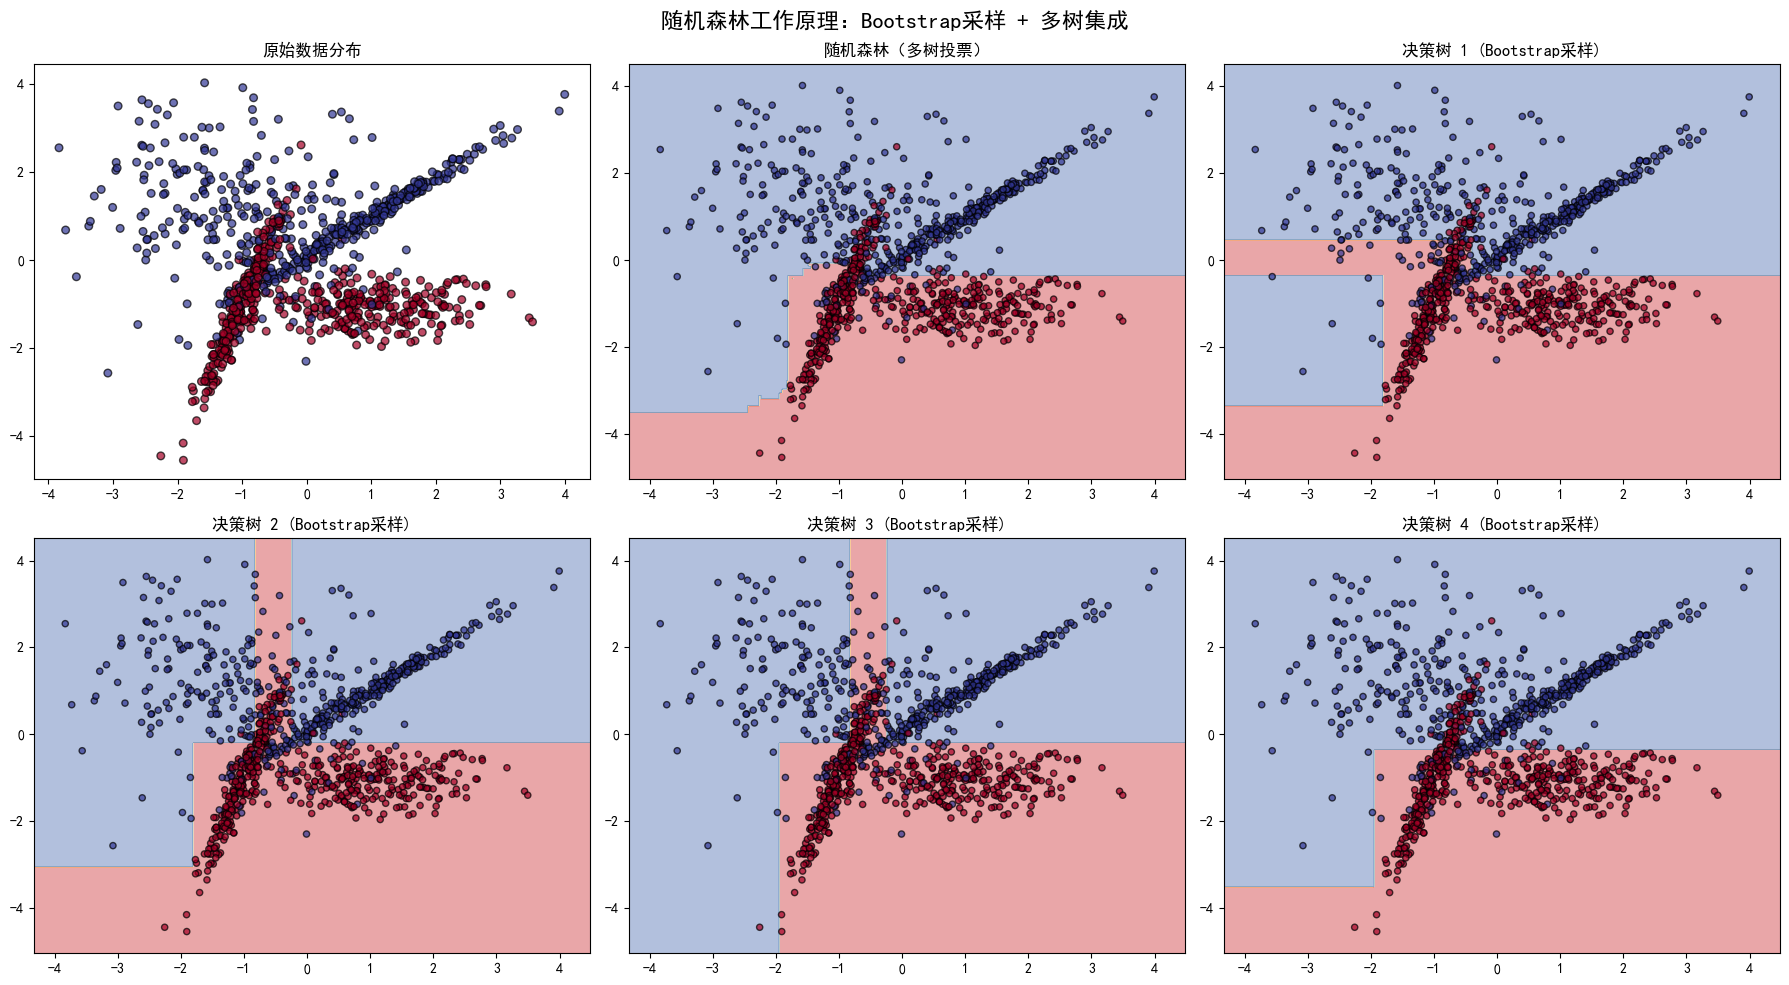

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ---------------------- 1. 生成数据 & 网格 ----------------------
X, y = make_classification(
    n_samples=1000, n_features=2, n_informative=2,
    n_redundant=0, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# ---------------------- 2. 画图布局：2行3列 ----------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # 变成一维，方便索引

# ===================== 子图 1：原始数据 =====================
ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', alpha=0.7, edgecolors='k', s=30)
ax.set_title('原始数据分布', fontsize=12, fontweight='bold')

# ===================== 子图 2：随机森林（Bootstrap集成） =====================
ax = axes[1]
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf.fit(X_train, y_train)
Z_rf = rf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z_rf, cmap='RdYlBu', alpha=0.4)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', alpha=0.7, edgecolors='k', s=20)
ax.set_title('随机森林（多树投票）', fontsize=12, fontweight='bold')

# ===================== 子图3~6：4棵 Bootstrap 决策树 =====================
for i in range(4):
    ax = axes[i+2]
    
    # Bootstrap 抽样（核心：随机有放回采样）
    idx = np.random.choice(len(X_train), len(X_train), replace=True)
    X_boot, y_boot = X_train[idx], y_train[idx]
    
    # 训练单棵决策树
    tree = DecisionTreeClassifier(max_depth=3, random_state=i)
    tree.fit(X_boot, y_boot)
    
    # 预测 & 画边界
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap='RdYlBu', alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', alpha=0.7, edgecolors='k', s=20)
    ax.set_title(f'决策树 {i+1} (Bootstrap采样)', fontsize=12, fontweight='bold')

# ---------------------- 整体设置 ----------------------
plt.suptitle('随机森林工作原理：Bootstrap采样 + 多树集成', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
可以看到图4,5,6单棵树决策边界不稳定，说明易过拟合；而随机森林通过多树投票，得到更平滑、泛化能力更强的决策边界，体现了集成学习的核心优势。

---

## 四、随机森林的关键参数

这几个参数最常用，先搞懂它们：
| 参数名 | 含义 | 典型值/影响 | 通俗解释 |
| :--- | :--- | :--- | :--- |
| **n_estimators** | 森林中决策树的数量 | 默认 100。值越大，模型通常越稳定，性能越好，但计算成本也越高。 | "委员会的人数"。人越多，决策通常越可靠，但开会时间也更长。 |
| **max_depth** | 单棵决策树的最大深度 | 默认 None（不限制）。限制深度可以防止过拟合，使模型更简单。 | "限制每个人的发言时间"。防止某个专家（树）钻牛角尖。 |
| **max_features** | 寻找最佳分裂时考虑的特征数 | 默认 'sqrt'。引入"特征随机性"的关键参数。 | "每次讨论只随机看几个方面"。确保每棵树角度不同。 |
| **min_samples_split** | 节点分裂所需的最小样本数 | 默认 2。值越大，树生长越保守，越不容易过拟合。 | "一个小组至少要有几个人才能继续分组"。避免规则太细。 |
| **min_samples_leaf** | 叶节点所需的最小样本数 | 默认 1。值越大，模型边界越平滑。 | "最终结论至少需要基于几个案例"。保证结论稳健。 |
| **bootstrap** | 是否使用 Bootstrap 采样 | 默认 True。Bagging 的核心精髓。 | "是否随机有放回选数据"。保证每棵树训练样本不同。 |

画图演示一下树的数量（n_estimators）对性能的影响。


参数影响演示:
 n_estimators  mean_accuracy      std
            1          0.888 0.016000
           10          0.921 0.012410
           50          0.921 0.015297
          100          0.920 0.011402
          200          0.918 0.011662


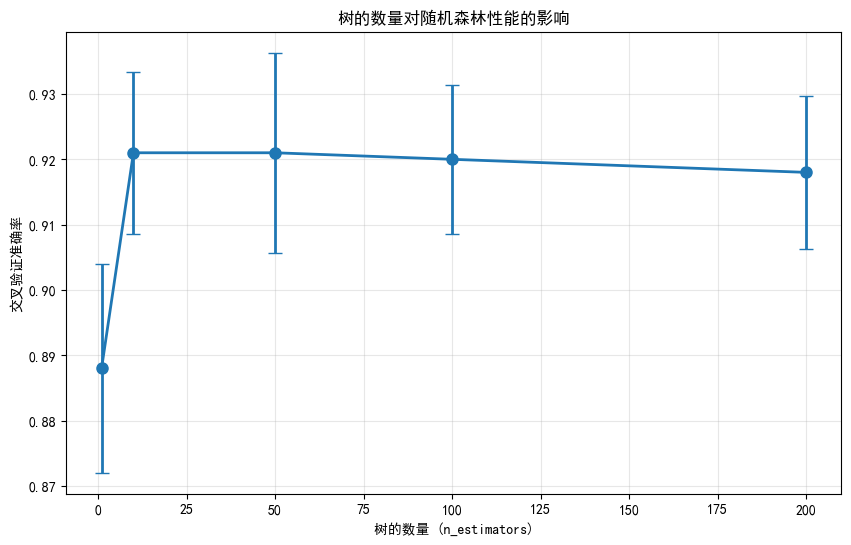

In [58]:
# 参数调优示例
print("\n参数影响演示:")

n_estimators_list = [1, 10, 50, 100, 200]
results = []

for n in n_estimators_list:
    rf_n = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(rf_n, X, y, cv=5)
    results.append({
        'n_estimators': n,
        'mean_accuracy': scores.mean(),
        'std': scores.std()
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# 可视化
plt.figure(figsize=(10, 6))
plt.errorbar(results_df['n_estimators'], results_df['mean_accuracy'], 
             yerr=results_df['std'], marker='o', capsize=5, linewidth=2, markersize=8)
plt.xlabel('树的数量 (n_estimators)')
plt.ylabel('交叉验证准确率')
plt.title('树的数量对随机森林性能的影响')
plt.grid(True, alpha=0.3)
plt.show()

可以看到，随着随机森林中决策树数量（n_estimators）的增加，模型准确率快速提升并迅速达到饱和状态。当树数量较少时（1 棵），模型性能较弱且稳定性差；增加至 10–50 棵时，性能达到最优；继续增加树数量不会带来明显性能增益，但能提升模型稳定性。这体现了随机森林 **“集成学习降低方差、提升泛化能力”** 的核心优势。

---

## 五、特征重要性

随机森林跟决策树一样，可以评估每个特征对预测的贡献程度，也是用模型返回的feature_importances_。


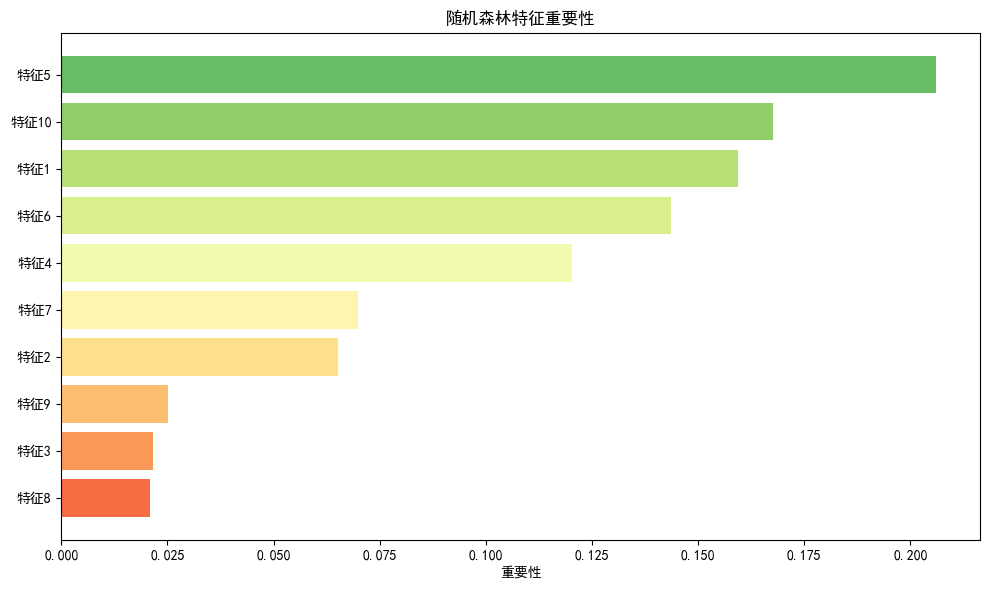

特征重要性排名:
  特征      重要性
 特征5 0.206109
特征10 0.167711
 特征1 0.159516
 特征6 0.143680
 特征4 0.120340
 特征7 0.069936
 特征2 0.065147
 特征9 0.025048
 特征3 0.021608
 特征8 0.020905


In [60]:
# 生成分类数据
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5,
                           n_redundant=2, n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 训练随机森林获取特征重要性
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_imp.fit(X_train, y_train)

feature_names = [f'特征{i+1}' for i in range(10)]
importance_df = pd.DataFrame({
    '特征': feature_names,
    '重要性': rf_imp.feature_importances_
}).sort_values('重要性', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importance_df)))
plt.barh(importance_df['特征'], importance_df['重要性'], color=colors)
plt.xlabel('重要性')
plt.title('随机森林特征重要性')
plt.tight_layout()
plt.show()
print("特征重要性排名:")
print(importance_df.sort_values('重要性', ascending=False).to_string(index=False))


---

## 六、OOB分数：自带验证集

随机森林有个超实用的特性：**OOB (Out-of-Bag) 分数**

它可以让你不需要单独划分测试集，也不需要做复杂的交叉验证，就能免费得到一个准确、客观的模型评估得分。

用一句话来解释它的精髓：“数据利用的最高境界——边训练，边当自己的主考官。”

**它是怎么来的？**

Bootstrap 抽样会随机有放回选数据，大概 37% 的数据永远不会被抽到，这些没被抽到的数据，就叫 袋外数据（OOB），随机森林可以直接用这些数据做测试，得到的分数就是 OOB 分数。所有的原始数据都参与了模型的完整训练，没有浪费一兵一卒，数据零浪费。它是在模型训练的过程中顺手计算出来的，不需要你再额外跑几折循环，速度极快，计算零等待。

在统计学上已经证明，OOB 分数对模型泛化能力的评估，与极其耗时的交叉验证（Cross-Validation）几乎完全一样准确。

**如何在 Python 中开启 OOB 隐藏外挂？**
在 scikit-learn 中，随机森林默认是关闭 OOB 计算的。你只需要在实例化模型时，随手加上一个参数 oob_score=True，就能白嫖到这个分数


OOB分数: 0.9237
测试集准确率: 0.9450

OOB分数≈交叉验证分数，省去了额外划分验证集！


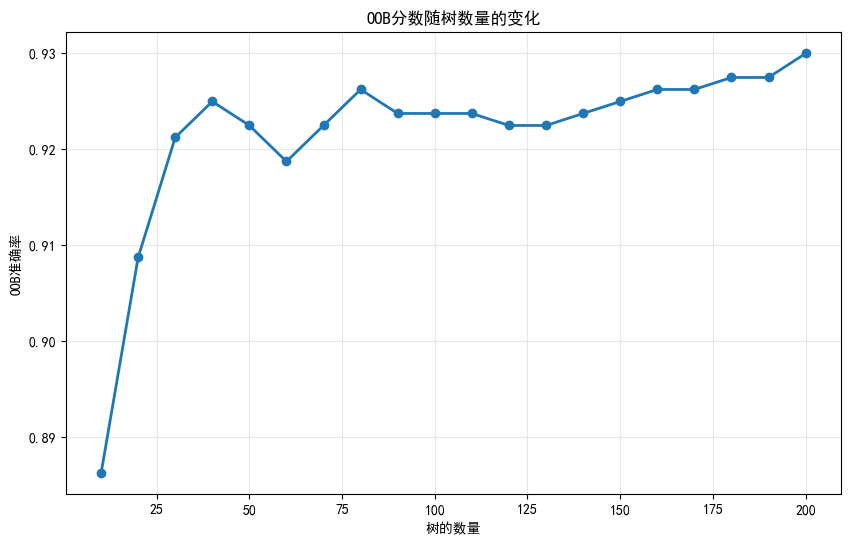

In [61]:
# OOB分数演示
rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print(f"\nOOB分数: {rf_oob.oob_score_:.4f}")
print(f"测试集准确率: {accuracy_score(y_test, rf_oob.predict(X_test)):.4f}")
print("\nOOB分数≈交叉验证分数，省去了额外划分验证集！")

# OOB分数随树数量变化
oob_scores = []
for n in range(10, 201, 10):
    rf_temp = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf_temp.fit(X_train, y_train)
    oob_scores.append(rf_temp.oob_score_)

plt.figure(figsize=(10, 6))
plt.plot(range(10, 201, 10), oob_scores, marker='o', linewidth=2)
plt.xlabel('树的数量')
plt.ylabel('OOB准确率')
plt.title('OOB分数随树数量的变化')
plt.grid(True, alpha=0.3)
plt.show()

---

## 七、综合实战：手写数字识别

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


 综合实战：手写数字识别
数据形状: (1797, 64)
类别: 0-9 共10个数字
图像大小: 8x8 = 64像素


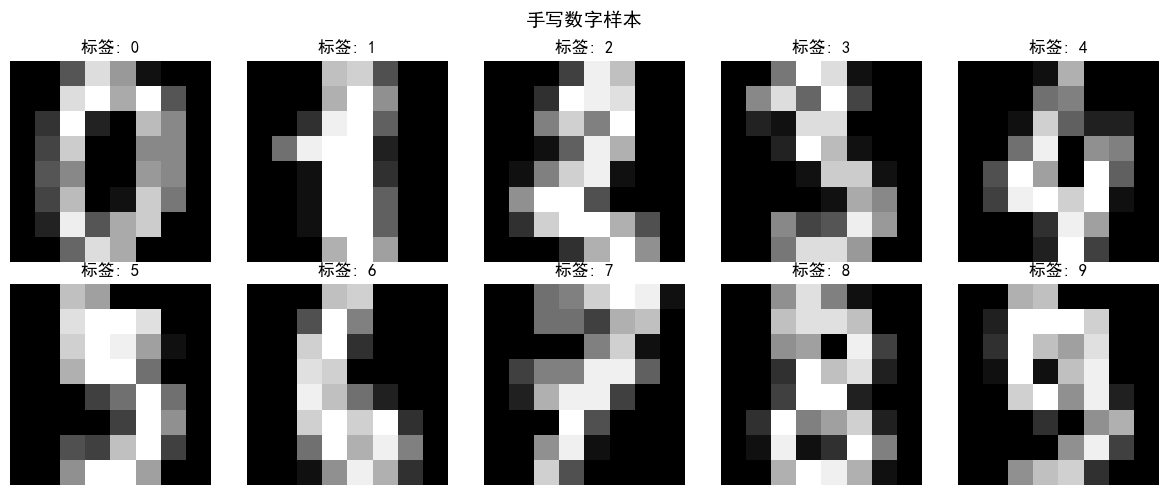

In [72]:
print(" 综合实战：手写数字识别")

# 加载手写数字数据集
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

print(f"数据形状: {X_digits.shape}")
print(f"类别: 0-9 共{digits.target_names.shape[0]}个数字")
print(f"图像大小: 8x8 = 64像素")

# 可视化一些样本
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'标签: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('手写数字样本', fontsize=14)
plt.tight_layout()
plt.show()


样本看完了，正式开始建模——对比决策树和随机森林的效果：


In [73]:
# 划分数据
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42)

# 对比不同模型
models = {
    '决策树': DecisionTreeClassifier(random_state=42),
    '随机森林(50棵)': RandomForestClassifier(n_estimators=50, random_state=42),
    '随机森林(100棵)': RandomForestClassifier(n_estimators=100, random_state=42),
    '随机森林(200棵)': RandomForestClassifier(n_estimators=200, random_state=42),
}

print("\n模型对比:")
print("-" * 50)

results = []
for name, model in models.items():
    model.fit(X_train_d, y_train_d)
    train_acc = accuracy_score(y_train_d, model.predict(X_train_d))
    test_acc = accuracy_score(y_test_d, model.predict(X_test_d))
    results.append({'模型': name, '训练准确率': train_acc, '测试准确率': test_acc})
    print(f"{name:15s} 训练: {train_acc:.4f}  测试: {test_acc:.4f}")

results_df = pd.DataFrame(results)



模型对比:
--------------------------------------------------
决策树             训练: 1.0000  测试: 0.8417
随机森林(50棵)       训练: 1.0000  测试: 0.9722
随机森林(100棵)      训练: 1.0000  测试: 0.9722
随机森林(200棵)      训练: 1.0000  测试: 0.9694


数字对比不够直观，画图更一目了然：


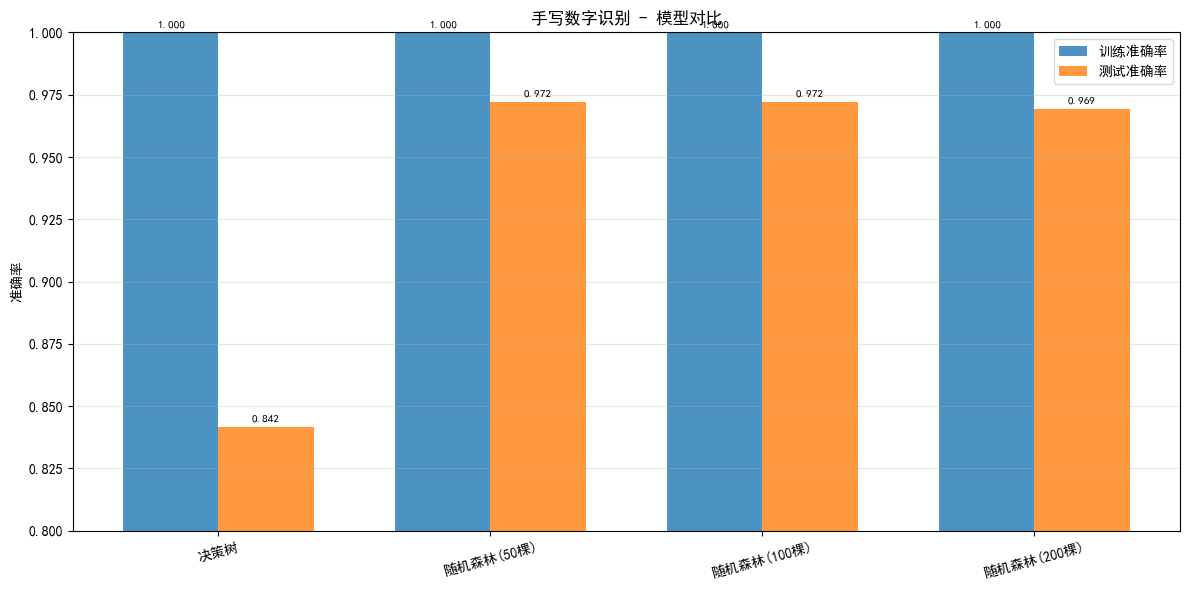

In [63]:
# 可视化对比
x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, results_df['训练准确率'], width, label='训练准确率', alpha=0.8)
bars2 = ax.bar(x + width/2, results_df['测试准确率'], width, label='测试准确率', alpha=0.8)

ax.set_ylabel('准确率')
ax.set_title('手写数字识别 - 模型对比')
ax.set_xticks(x)
ax.set_xticklabels(results_df['模型'], rotation=15)
ax.legend()
ax.set_ylim(0.8, 1.0)
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


可以看到随机森林比决策树都高了10+%。 但是准确率再高也有失误的时候，看看模型都错在哪了：



预测错误: 10 / 360 (2.8%)


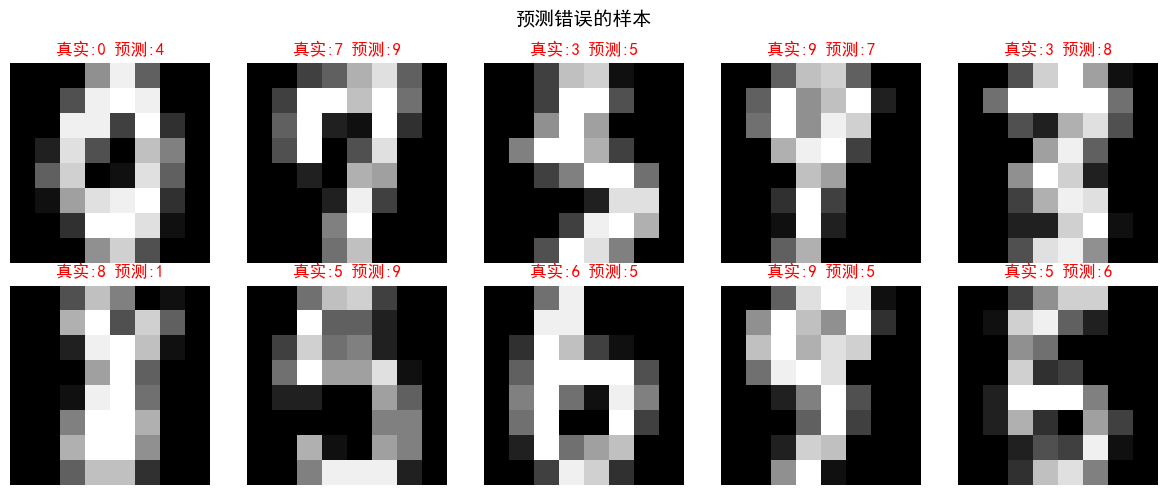

In [65]:
# 查看预测错误的样本
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_d, y_train_d)
y_pred_d = best_model.predict(X_test_d)

# 找出错误
errors = y_pred_d != y_test_d
error_indices = np.where(errors)[0]

print(f"\n预测错误: {len(error_indices)} / {len(y_test_d)} ({errors.mean():.1%})")

# 可视化错误
if len(error_indices) > 0:
    n_show = min(10, len(error_indices))
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for idx, ax in enumerate(axes.flat[:n_show]):
        i = error_indices[idx]
        ax.imshow(X_test_d[i].reshape(8, 8), cmap='gray')
        ax.set_title(f'真实:{y_test_d[i]} 预测:{y_pred_d[i]}', color='red')
        ax.axis('off')
    plt.suptitle('预测错误的样本', fontsize=14)
    plt.tight_layout()
    plt.show()


---

## 八、小结

| 特性 | 决策树 | 随机森林 |
|------|--------|----------|
| **准确率** | 一般 | 高 |
| **稳定性** | 低（数据变化影响大） | 高 |
| **过拟合** | 容易 | 不易 |
| **训练速度** | 快 | 慢（但可并行） |
| **可解释性** | 强 | 中等（特征重要性） |
| **需要调参** | 较少 | 较多 |

**随机森林的优点**：
- 准确率高、泛化能力强
- 不易过拟合
- 自带特征重要性
- 自带OOB验证
- 天然支持并行训练

**适用场景**：
- 表格数据的分类/回归
- 作为基准模型（baseline）
- 需要特征重要性的场景

---

## 九、课后练习

1. 调整max_depth参数，观察对过拟合的影响
2. 对比不同max_features设置的效果
3. 用随机森林做回归任务（RandomForestRegressor）
4. 思考：为什么随机森林不容易过拟合？

练习1：max_depth对过拟合的影响
  max_depth=   1: 训练=0.8225, 测试=0.8650, 差距=-0.0425
  max_depth=   2: 训练=0.8750, 测试=0.8950, 差距=-0.0200
  max_depth=   3: 训练=0.9062, 测试=0.9100, 差距=-0.0038
  max_depth=   5: 训练=0.9525, 测试=0.9300, 差距=0.0225
  max_depth=   7: 训练=0.9825, 测试=0.9600, 差距=0.0225
  max_depth=  10: 训练=0.9988, 测试=0.9550, 差距=0.0438
  max_depth=  15: 训练=1.0000, 测试=0.9500, 差距=0.0500
  max_depth=  20: 训练=1.0000, 测试=0.9450, 差距=0.0550
  max_depth=None: 训练=1.0000, 测试=0.9450, 差距=0.0550


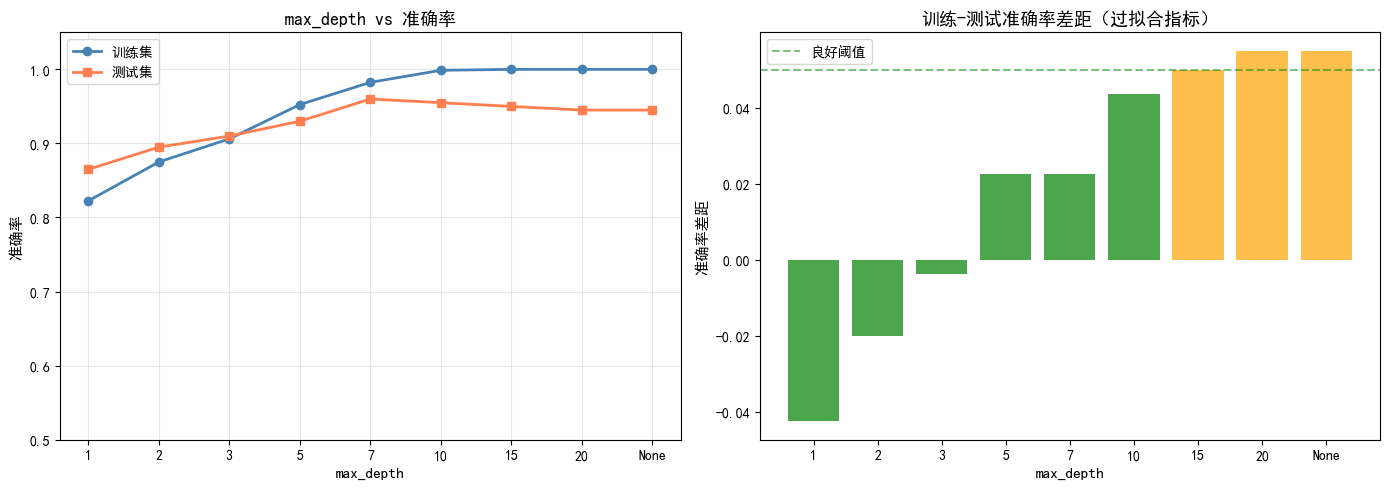

In [66]:
print("练习1：max_depth对过拟合的影响")

depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
train_accs = []
test_accs = []

for depth in depths:
    rf = RandomForestClassifier(max_depth=depth, n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    train_acc = rf.score(X_train, y_train)
    test_acc = rf.score(X_test, y_test)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    depth_str = str(depth) if depth is not None else 'None'
    print(f"  max_depth={depth_str:>4s}: 训练={train_acc:.4f}, 测试={test_acc:.4f}, 差距={train_acc-test_acc:.4f}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

depth_labels = [str(d) if d is not None else 'None' for d in depths]
axes[0].plot(depth_labels, train_accs, 'o-', label='训练集', color='steelblue', linewidth=2, markersize=6)
axes[0].plot(depth_labels, test_accs, 's-', label='测试集', color='coral', linewidth=2, markersize=6)
axes[0].set_title('max_depth vs 准确率', fontsize=13)
axes[0].set_xlabel('max_depth', fontsize=11)
axes[0].set_ylabel('准确率', fontsize=11)
axes[0].legend()
axes[0].set_ylim(0.5, 1.05)
axes[0].grid(True, alpha=0.3)

# 过拟合差距
gaps = [t - te for t, te in zip(train_accs, test_accs)]
axes[1].bar(depth_labels, gaps, color=['green' if g < 0.05 else 'orange' if g < 0.1 else 'red' for g in gaps], alpha=0.7)
axes[1].set_title('训练-测试准确率差距（过拟合指标）', fontsize=13)
axes[1].set_xlabel('max_depth', fontsize=11)
axes[1].set_ylabel('准确率差距', fontsize=11)
axes[1].axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='良好阈值')
axes[1].legend()

plt.tight_layout()
plt.show()

练习2：不同max_features设置的效果
数据共有 10 个特征
  max_features=      sqrt (= 3): 训练=1.0000, 测试=0.9450
  max_features=      log2 (= 3): 训练=1.0000, 测试=0.9450
  max_features=      None (= 10): 训练=1.0000, 测试=0.9650
  max_features=         1 (= 1): 训练=1.0000, 测试=0.9250
  max_features=         2 (= 2): 训练=1.0000, 测试=0.9550


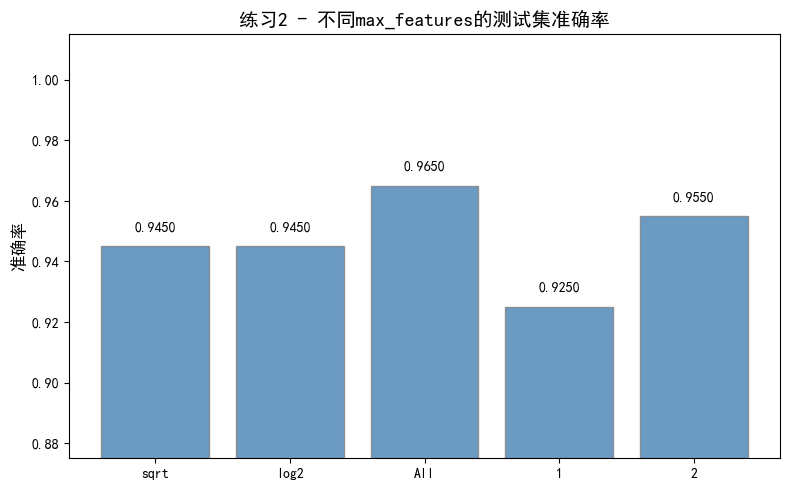

In [67]:
print("练习2：不同max_features设置的效果")
print("=" * 60)

n_features = X_train.shape[1]
max_features_options = {
    'sqrt': int(np.sqrt(n_features)),
    'log2': int(np.log2(n_features)),
    None: n_features,
    1: 1,
    2: 2
}

print(f"数据共有 {n_features} 个特征")
for name, val in max_features_options.items():
    rf = RandomForestClassifier(max_features=name if isinstance(name, str) else val,
                                n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    train_acc = rf.score(X_train, y_train)
    test_acc = rf.score(X_test, y_test)
    print(f"  max_features={str(name):>10s} (= {val}): 训练={train_acc:.4f}, 测试={test_acc:.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(8, 5))
feature_names = [str(name) if name is not None else 'All' for name in max_features_options.keys()]
test_scores = []
for name, val in max_features_options.items():
    rf = RandomForestClassifier(max_features=name if isinstance(name, str) else val,
                                n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    test_scores.append(rf.score(X_test, y_test))

bars = ax.bar(feature_names, test_scores, color='steelblue', alpha=0.8, edgecolor='gray')
for bar, v in zip(bars, test_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('练习2 - 不同max_features的测试集准确率', fontsize=14)
ax.set_ylabel('准确率', fontsize=12)
ax.set_ylim(min(test_scores) - 0.05, max(test_scores) + 0.05)
plt.tight_layout()
plt.show()

练习3：随机森林回归任务
回归数据集: 训练集350条, 测试集150条
目标变量范围: [-191.8, 198.6]

随机森林回归结果:
  RMSE: 33.6492
  R²: 0.7803

不同max_depth的回归性能:
  max_depth=   3: RMSE=42.74, R²=0.6456
  max_depth=   5: RMSE=35.75, R²=0.7519
  max_depth=   7: RMSE=33.91, R²=0.7768
  max_depth=  10: RMSE=33.65, R²=0.7803
  max_depth=  15: RMSE=33.54, R²=0.7817
  max_depth=None: RMSE=33.53, R²=0.7818


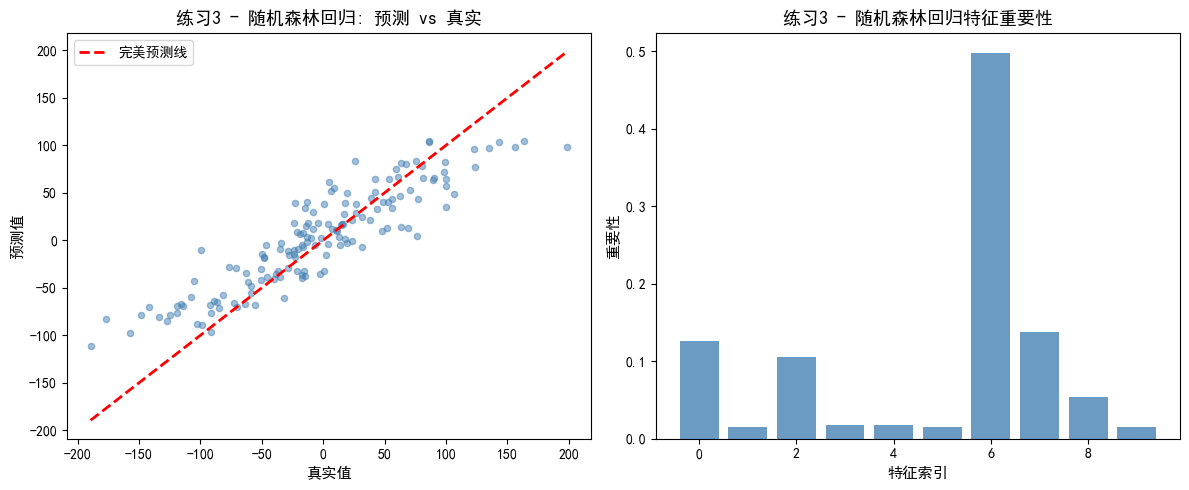

In [71]:
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, roc_curve, auc,
                            precision_score, recall_score, f1_score,
                            mean_squared_error, r2_score)
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

print("练习3：随机森林回归任务")
print("=" * 60)

# 生成回归数据
X_reg, y_reg = make_regression(n_samples=500, n_features=10, n_informative=5,
                                noise=20, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

print(f"回归数据集: 训练集{X_train_r.shape[0]}条, 测试集{X_test_r.shape[0]}条")
print(f"目标变量范围: [{y_reg.min():.1f}, {y_reg.max():.1f}]")

# 训练随机森林回归
rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rfr.fit(X_train_r, y_train_r)
y_pred_r = rfr.predict(X_test_r)

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)
print(f"\n随机森林回归结果:")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²: {r2:.4f}")

# 对比不同max_depth
print(f"\n不同max_depth的回归性能:")
depths_reg = [3, 5, 7, 10, 15, None]
for depth in depths_reg:
    rfr = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42)
    rfr.fit(X_train_r, y_train_r)
    y_pred = rfr.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2 = r2_score(y_test_r, y_pred)
    d_str = str(depth) if depth is not None else 'None'
    print(f"  max_depth={d_str:>4s}: RMSE={rmse:.2f}, R²={r2:.4f}")

# 可视化：预测值 vs 真实值
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 散点图
rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rfr.fit(X_train_r, y_train_r)
y_pred_r = rfr.predict(X_test_r)
axes[0].scatter(y_test_r, y_pred_r, alpha=0.5, s=20, color='steelblue')
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()],
             'r--', linewidth=2, label='完美预测线')
axes[0].set_xlabel('真实值', fontsize=11)
axes[0].set_ylabel('预测值', fontsize=11)
axes[0].set_title('练习3 - 随机森林回归: 预测 vs 真实', fontsize=13)
axes[0].legend()

# 特征重要性
importances = rfr.feature_importances_
axes[1].bar(range(len(importances)), importances, color='steelblue', alpha=0.8)
axes[1].set_xlabel('特征索引', fontsize=11)
axes[1].set_ylabel('重要性', fontsize=11)
axes[1].set_title('练习3 - 随机森林回归特征重要性', fontsize=13)

plt.tight_layout()
plt.show()

A: 1. Bagging（装袋法）机制：
      - 随机森林通过有放回抽样（Bootstrap）从训练集中生成多个子数据集
      - 每棵树只看到约63.2%的不同样本（约36.8%的样本不会被看到，称为OOB样本）
      - 多棵独立训练的树进行投票/平均，降低了单棵树的方差

   2. 随机特征选择：
      - 每次分裂时，随机森林只考虑特征的随机子集（而非全部特征）
      - 这使得各棵树的相关性降低，集成效果更好
      - 即使单棵树过拟合，不同树过拟合的方向不同，平均后相互抵消

   3. 数学直觉：
      - 假设每棵树的相关系数为 ρ，单棵树方差为 σ²
      - 集成后方差 = ρσ² + (1-ρ)σ²/n
      - 随着树的数量n增加，方差趋向于 ρσ²
      - 因为 ρ < 1（树之间不完全相同），所以方差被显著降低

   4. 对比单棵决策树：
      - 决策树会不断分裂直到叶子节点纯净，很容易记住训练数据的噪声
      - 随机森林中每棵树虽然也可能过拟合，但投票机制平滑了这种过拟合

   5. 注意：随机森林并非完全不会过拟合
      - 当 max_depth 过大且树的数量过多时，仍可能出现轻微过拟合
      - 但相比单棵决策树，过拟合程度要小得多

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 51 篇：支持向量机 SVM**
>
> 下篇学支持向量机——一种几何感很强的分类算法，核心思想是「找一条最宽的间隔线分开两类数据」。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*